# 🩺 **Diabetes Risk Prediction**

Dự án xây dựng mô hình Machine Learning dự đoán nguy cơ mắc bệnh tiểu đường dựa trên các chỉ số sức khỏe và lối sống.

**Mục tiêu:**
- Khám phá dữ liệu
- Xây dựng mô hình dự đoán
- So sánh các mô hình
- Đánh giá mô hình tốt nhất

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


In [2]:
# Visualization Settings

import matplotlib.pyplot as plt
import seaborn as sns

# Theme
sns.set_theme(style="whitegrid", context="notebook")

# Figure
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 120

# Font
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

# Title
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.titleweight"] = "bold"

# Axis labels
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"

# Tick labels
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Legend
plt.rcParams["legend.fontsize"] = 10

# Remove top & right border
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = [
    "#BFDBFE",  # Light Blue
    "#60A5FA",  # Blue
    "#2563EB",  # Strong Blue
    "#4F46E5",  # Indigo
    "#7C3AED"   # Violet
]

## **1. Dataset Overview**

### **1.1 Load Dataset**

In [3]:
import pandas as pd

df = pd.read_csv("data/raw/diabetes.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### **1.2 Dataset Information**

In [4]:
print(f"Shape: {df.shape}")

df.info()

df.describe().T

Shape: (253680, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


### **1.3. Nhóm biến trong bộ dữ liệu**

| Nhóm biến               | Biến                                                                      | Mô tả                                                                   |
| ----------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **Biến mục tiêu**       | `Diabetes_012`                                                            | Tình trạng tiểu đường (0: Không mắc, 1: Tiền tiểu đường, 2: Tiểu đường) |
| **Bệnh nền**            | `HighBP`, `HighChol`, `CholCheck`, `Stroke`, `HeartDiseaseorAttack`       | Các chỉ số liên quan đến bệnh tim mạch và cholesterol                   |
| **Lối sống**            | `BMI`, `Smoker`, `PhysActivity`, `Fruits`, `Veggies`, `HvyAlcoholConsump` | Thói quen sinh hoạt và chỉ số cơ thể                                    |
| **Tiếp cận y tế**       | `AnyHealthcare`, `NoDocbcCost`                                            | Khả năng tiếp cận và sử dụng dịch vụ y tế                               |
| **Tình trạng sức khỏe** | `GenHlth`, `MentHlth`, `PhysHlth`, `DiffWalk`                             | Đánh giá sức khỏe tổng quát, thể chất và tinh thần                      |
| **Nhân khẩu học**       | `Sex`, `Age`, `Education`, `Income`                                       | Đặc điểm cá nhân và kinh tế - xã hội                                    |


### **1.4. Nhận xét**

- Bộ dữ liệu gồm **253.680 quan sát** và **22 biến**, đủ lớn để xây dựng và đánh giá mô hình Machine Learning.
- Tất cả các biến đều có **253.680 giá trị hợp lệ (Non-Null)**, cho thấy dữ liệu **không có giá trị thiếu**.
- Các biến đều có kiểu dữ liệu `float64`. Hầu hết là các biến nhị phân hoặc biến rời rạc đã được mã hóa số, thuận lợi cho việc tiền xử lý và xây dựng mô hình.
- Chỉ số **BMI** dao động từ **12 đến 98**, cho thấy tồn tại một số giá trị rất lớn cần được kiểm tra thêm ở bước phân tích ngoại lệ.
- Biến mục tiêu **Diabetes_012** gồm **3 lớp (0, 1, 2)**, phù hợp với bài toán phân loại đa lớp trước khi chuyển đổi sang phân loại nhị phân.
- Nhiều biến như **HighBP, HighChol, Smoker, PhysActivity** là biến nhị phân (0/1), trong khi **BMI, MentHlth, PhysHlth** có nhiều mức giá trị hơn và có thể mang nhiều thông tin dự báo.

## **2. Data Cleaning**

### **2.1 Kiểm tra giá trị thiếu**

In [5]:
# Missing values
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

**Nhận xét**

Bộ dữ liệu không có giá trị thiếu, do đó không cần thực hiện xử lý thiếu dữ liệu trước khi xây dựng mô hình.

### **2.2 Kiểm tra dữ liệu trùng lặp**

In [6]:
# Duplicate records
print(f"Number of duplicated rows: {df.duplicated().sum()}")


Number of duplicated rows: 23899


In [7]:
df = df.drop_duplicates()

print(df.shape)

(229781, 22)


In [8]:
print(df.shape)
print(df.columns.tolist())
print(df.duplicated().sum())

(229781, 22)
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
0


 **Nhận xét**

- Bộ dữ liệu có **23.899 bản ghi trùng lặp**, chiếm khoảng **9,4%** tổng số quan sát.
- Các bản ghi trùng lặp đã được loại bỏ nhằm giảm nhiễu và tránh ảnh hưởng đến quá trình huấn luyện mô hình.
- Sau khi làm sạch, bộ dữ liệu còn **229.781 quan sát** và sẽ được sử dụng cho các bước phân tích tiếp theo.

### **2.3 Kiểm tra kiểu dữ liệu**

In [9]:
df.dtypes.value_counts()

float64    22
Name: count, dtype: int64

**Nhận xét**

- Tất cả **22 biến** trong bộ dữ liệu đều có kiểu dữ liệu `float64`.
- Phần lớn các biến là **biến nhị phân hoặc biến phân loại đã được mã hóa bằng số**, trong khi một số biến như `BMI`, `MentHlth` và `PhysHlth` là biến số liên tục hoặc có nhiều mức giá trị.
- Kiểu dữ liệu hiện tại phù hợp cho quá trình phân tích và xây dựng mô hình Machine Learning, chưa cần chuyển đổi kiểu dữ liệu.

## **3. Exploratory Data Analysis (EDA)**

### **3.1 Phân bố biến mục tiêu**

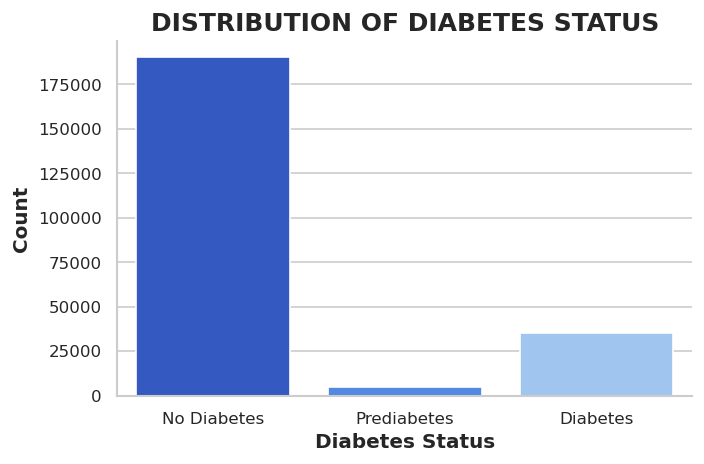

In [10]:
colors = ["#1D4ED8", "#3B82F6", "#93C5FD"]

plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Diabetes_012",
    hue="Diabetes_012",
    palette=colors,
    legend=False
)

plt.title("DISTRIBUTION OF DIABETES STATUS")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["No Diabetes", "Prediabetes", "Diabetes"]
)

plt.tight_layout()
plt.show()

**Nhận xét**

- Dữ liệu gồm ba nhóm: **No Diabetes**, **Prediabetes** và **Diabetes**.
- Nhóm **No Diabetes** chiếm đa số, trong khi **Prediabetes** có số lượng mẫu ít nhất, cho thấy bộ dữ liệu bị **mất cân bằng lớp**.
- Ở các bước tiếp theo, **Prediabetes** và **Diabetes** sẽ được gộp thành một lớp để xây dựng bài toán phân loại nhị phân và áp dụng các kỹ thuật xử lý mất cân bằng dữ liệu.

### **3.2 BMI Distribution**

BMI (Body Mass Index) là một trong những chỉ số quan trọng phản ánh tình trạng thể chất và được xem là yếu tố nguy cơ của bệnh tiểu đường. Phần này nhằm quan sát phân bố của chỉ số BMI trong bộ dữ liệu.

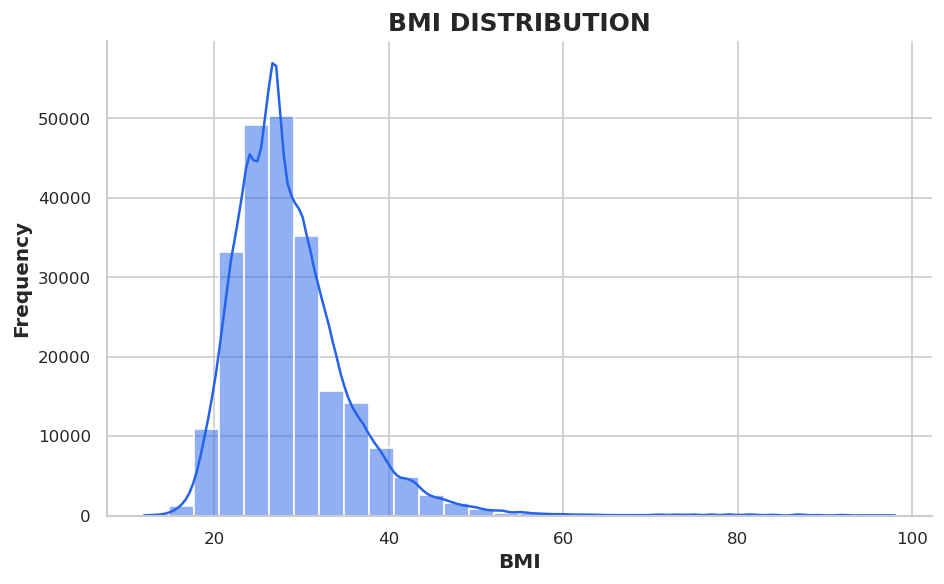

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="BMI",
    bins=30,
    kde=True,
    color="#2563EB",
    alpha=0.5
)

plt.title("BMI DISTRIBUTION")
plt.xlabel("BMI")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Nhận xét**

- Chỉ số BMI có phân bố **lệch phải (right-skewed)**, với phần lớn quan sát tập trung trong khoảng **20–35**.
- Đỉnh phân bố nằm khoảng **25–30**, cho thấy đây là khoảng BMI phổ biến nhất trong bộ dữ liệu.
- Xuất hiện một số giá trị BMI rất cao (lớn hơn 50), cho thấy có thể tồn tại các giá trị ngoại lệ cần được xem xét ở bước tiền xử lý.
- BMI là một trong những yếu tố nguy cơ quan trọng của bệnh tiểu đường, do đó sẽ tiếp tục được phân tích trong các bước tiếp theo.

### **3.3 BMI by Diabetes Status**

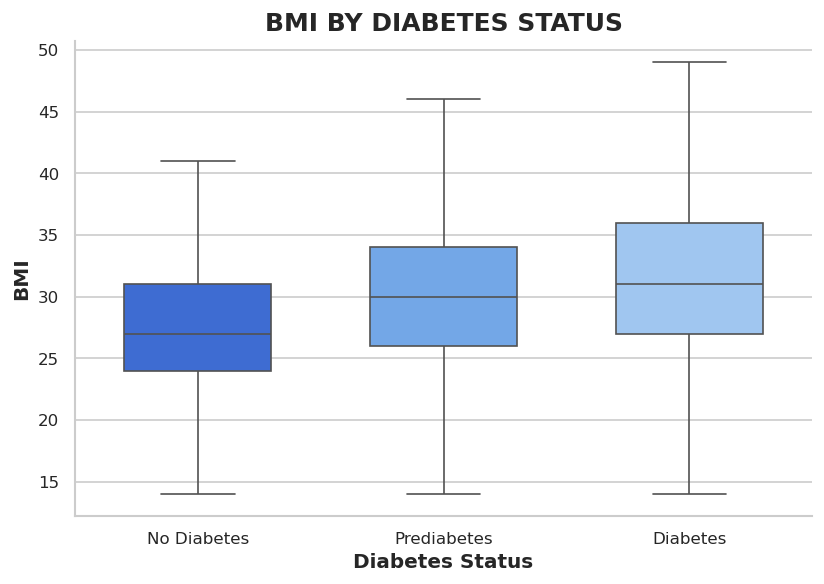

In [12]:
df_plot = df.copy()

df_plot["Diabetes Status"] = df_plot["Diabetes_012"].map({
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
})

# Order of categories
order = ["No Diabetes", "Prediabetes", "Diabetes"]

# Plot
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df_plot,
    x="Diabetes Status",
    y="BMI",
    order=order,
    palette=["#2563EB", "#60A5FA", "#93C5FD"],
    width=0.6,
    showfliers=False
)

plt.title("BMI BY DIABETES STATUS")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

**Nhận xét**

- Chỉ số BMI có sự khác biệt giữa ba nhóm tình trạng bệnh.
- Nhóm **Diabetes** có giá trị BMI trung vị (median) cao nhất, tiếp theo là **Prediabetes** và **No Diabetes**.
- Median BMI tăng dần từ **No Diabetes → Prediabetes → Diabetes**, cho thấy chỉ số BMI có xu hướng cao hơn ở các nhóm có nguy cơ hoặc đã mắc bệnh tiểu đường.
- Nhóm **Diabetes** có khoảng phân bố BMI (IQR) rộng hơn, phản ánh sự biến thiên lớn hơn về chỉ số BMI trong nhóm này.
- Kết quả cho thấy BMI là một đặc trưng có tiềm năng trong việc dự đoán nguy cơ mắc bệnh tiểu đường.

### **3.4 Age Distribution**


Phần này nhằm quan sát phân bố độ tuổi của người tham gia khảo sát. Biến **Age** trong bộ dữ liệu được mã hóa theo các nhóm tuổi thay vì giá trị tuổi thực tế.

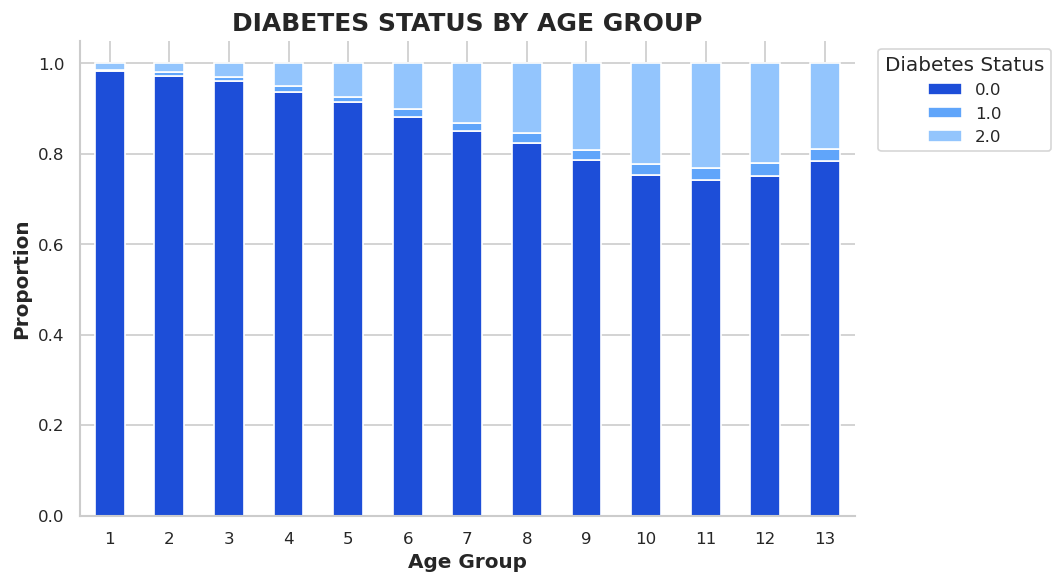

In [13]:
age_ratio = pd.crosstab(
    df["Age"],
    df["Diabetes_012"],
    normalize="index"
)

age_ratio.plot(
    kind="bar",
    stacked=True,
    figsize=(9,5),
    color=["#1D4ED8", "#60A5FA", "#93C5FD"]
)

plt.title("DIABETES STATUS BY AGE GROUP")
plt.xlabel("Age Group")
plt.xticks(
    ticks=range(13),
    labels=range(1,14),
    rotation=0
)
plt.ylabel("Proportion")

plt.legend(
    title="Diabetes Status",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True
)

plt.tight_layout()
plt.show()

**Nhận xét**

- Ở các nhóm tuổi thấp (1–5), **No Diabetes** chiếm gần như toàn bộ số quan sát.
- Khi nhóm tuổi tăng, tỷ lệ **No Diabetes** có xu hướng giảm, trong khi tỷ lệ **Prediabetes** và **Diabetes** tăng dần.
- Nhóm tuổi từ **9 đến 12** có tỷ lệ mắc bệnh và tiền tiểu đường cao nhất.
- Kết quả cho thấy **Age** có mối liên hệ rõ ràng với nguy cơ mắc bệnh tiểu đường và là một đặc trưng quan trọng trong quá trình xây dựng mô hình dự đoán.

### **3.5 Correlation Analysis**

Để hiểu mối quan hệ tuyến tính giữa các đặc trưng trong bộ dữ liệu, ma trận tương quan được sử dụng. Kết quả giúp xác định các đặc trưng có liên hệ với biến mục tiêu và kiểm tra hiện tượng đa cộng tuyến.

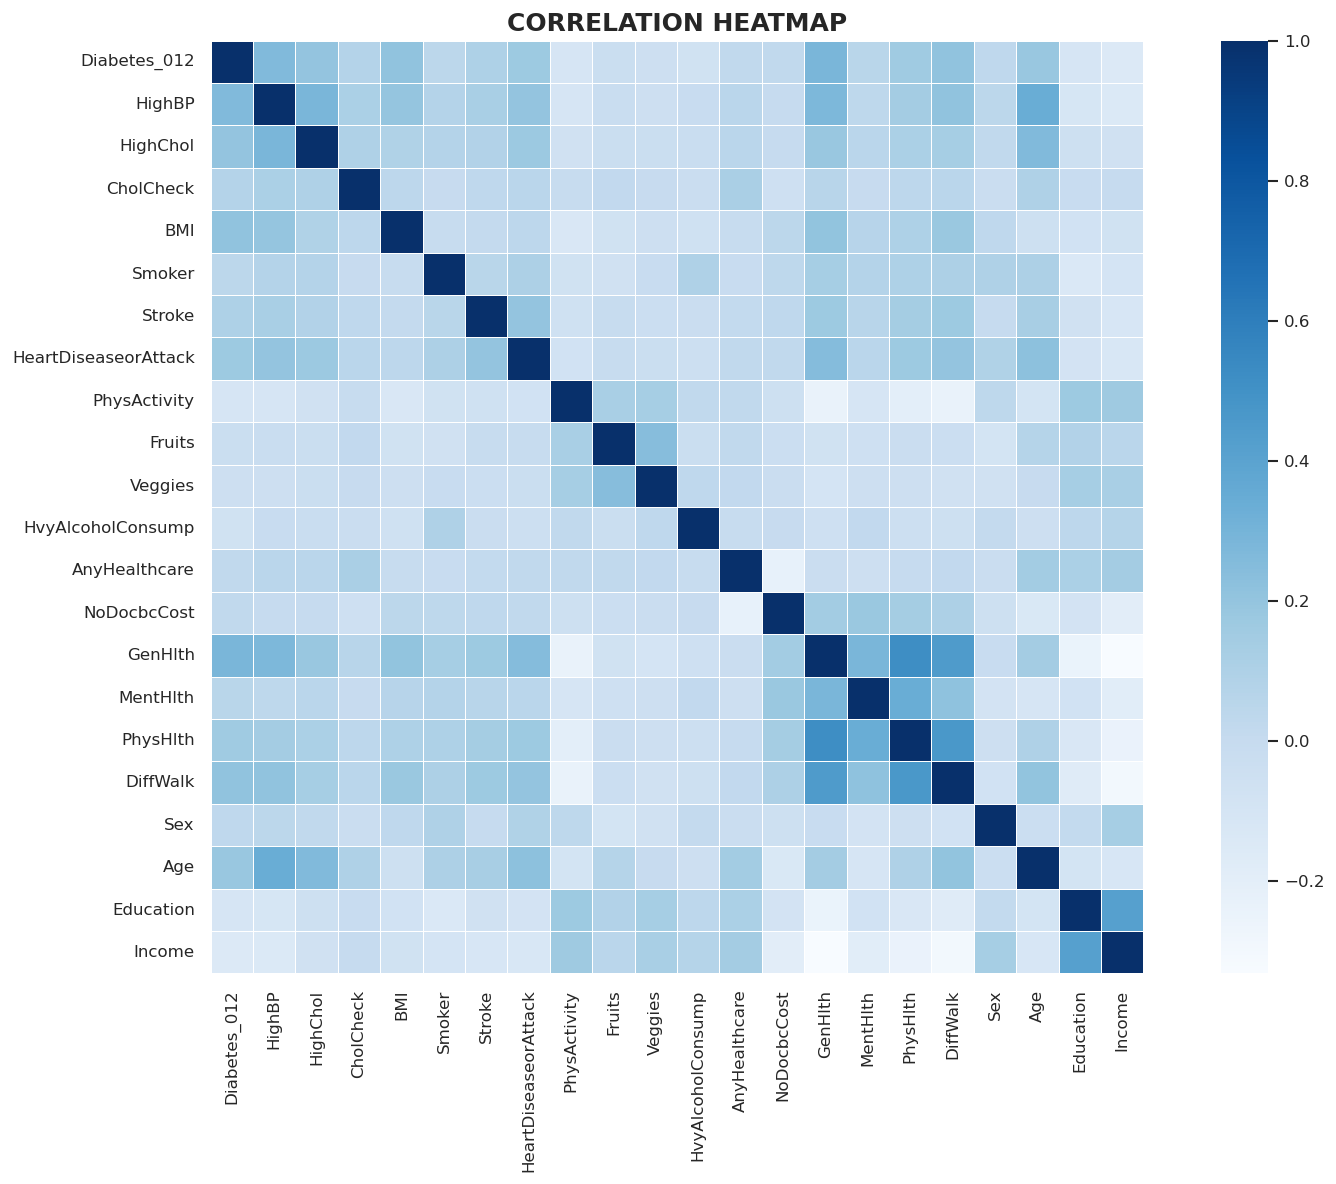

In [14]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="Blues",
    annot=False,
    square=True,
    linewidths=0.5
)

plt.title("CORRELATION HEATMAP")

plt.tight_layout()
plt.show()

**Nhận xét**

- Phần lớn các đặc trưng chỉ có mức tương quan thấp đến trung bình, cho thấy hiện tượng đa cộng tuyến không đáng kể.
- Một số đặc trưng như **GenHlth**, **BMI**, **HighBP**, **Age** và **DiffWalk** có mức tương quan cao hơn với biến mục tiêu **Diabetes_012**.
- Các đặc trưng sức khỏe có xu hướng tương quan với nhau, tuy nhiên không xuất hiện cặp biến nào có hệ số tương quan quá cao (|r| > 0.8).
- Kết quả này cho thấy các biến đều có khả năng đóng góp thông tin cho mô hình và sẽ được đánh giá thêm bằng phương pháp Mutual Information ở bước tiếp theo.

## **4. Feature Engineering & Selection**

### **4.1 Create Binary Target**

Biến mục tiêu ban đầu (**Diabetes_012**) gồm ba lớp:

- 0: No Diabetes
- 1: Prediabetes
- 2: Diabetes

Trong dự án này, bài toán được chuyển thành **phân loại nhị phân** nhằm phát hiện người có nguy cơ mắc bệnh.

Do đó:

- 0 → No Diabetes
- 1 và 2 → Diabetes Risk

Việc chuyển đổi được thực hiện vì các lý do sau:

- **Phù hợp với mục tiêu của dự án:** Mục tiêu là phát hiện những người có nguy cơ mắc bệnh tiểu đường để hỗ trợ sàng lọc sớm. Do đó, cả nhóm **Prediabetes** và **Diabetes** đều được xem là nhóm có nguy cơ.

- **Giảm mất cân bằng dữ liệu:** Trong bộ dữ liệu gốc, lớp **Prediabetes** có số lượng mẫu rất ít so với hai lớp còn lại. Điều này khiến mô hình đa lớp khó học và thường cho kết quả dự đoán kém đối với lớp này. Sau khi gộp, tỷ lệ giữa hai lớp trở nên cân bằng hơn, giúp mô hình học hiệu quả hơn.

- **Đơn giản hóa bài toán:** Thay vì phân biệt ba trạng thái sức khỏe, mô hình chỉ cần xác định người tham gia có thuộc nhóm nguy cơ mắc bệnh hay không. Điều này giúp việc huấn luyện và đánh giá mô hình trở nên đơn giản hơn.

In [15]:
# số lượng mẫu trước và sau khi gộp
print(f"Số lượng mẫu trước khi gộp: {df['Diabetes_012'].value_counts()}" )

df["Diabetes_binary"] = df["Diabetes_012"].replace({
    0: 0,
    1: 1,
    2: 1
})

# Remove original target
df = df.drop(columns=["Diabetes_012"])

print(f"Số lượng mẫu sau khi gộp: {df['Diabetes_binary'].value_counts()}" )

Số lượng mẫu trước khi gộp: Diabetes_012
0.0    190055
2.0     35097
1.0      4629
Name: count, dtype: int64
Số lượng mẫu sau khi gộp: Diabetes_binary
0.0    190055
1.0     39726
Name: count, dtype: int64


**Nhận xét**

Lớp Prediabetes có số lượng mẫu rất nhỏ, dẫn đến hiện tượng mất cân bằng giữa các lớp trong bài toán phân loại đa lớp. Việc gộp Prediabetes và Diabetes giúp giảm mức độ mất cân bằng và tăng khả năng học của mô hình.

### **4.2 Feature Selection using Mutual Information**

Sau khi xây dựng biến mục tiêu nhị phân, tiến hành đánh giá mức độ đóng góp của từng đặc trưng bằng phương pháp **Mutual Information (MI)**.

Mutual Information đo lường lượng thông tin mà mỗi đặc trưng cung cấp cho biến mục tiêu. Giá trị MI càng lớn cho thấy đặc trưng càng hữu ích trong việc dự đoán nguy cơ mắc bệnh tiểu đường.

Kết quả MI sẽ được sử dụng làm cơ sở để lựa chọn các đặc trưng trước khi xây dựng mô hình.

In [16]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_scores = pd.Series(
    mi_scores,
    index=X.columns
).sort_values(ascending=False)

mi_scores

HighBP                  0.053335
GenHlth                 0.048509
AnyHealthcare           0.046209
CholCheck               0.044222
PhysActivity            0.043200
HighChol                0.037819
Veggies                 0.035877
Fruits                  0.032244
BMI                     0.030151
Age                     0.025977
Smoker                  0.023811
DiffWalk                0.021157
Sex                     0.020212
Education               0.019379
Income                  0.018179
PhysHlth                0.012498
HeartDiseaseorAttack    0.011395
MentHlth                0.003661
Stroke                  0.002871
HvyAlcoholConsump       0.002371
NoDocbcCost             0.000044
dtype: float64

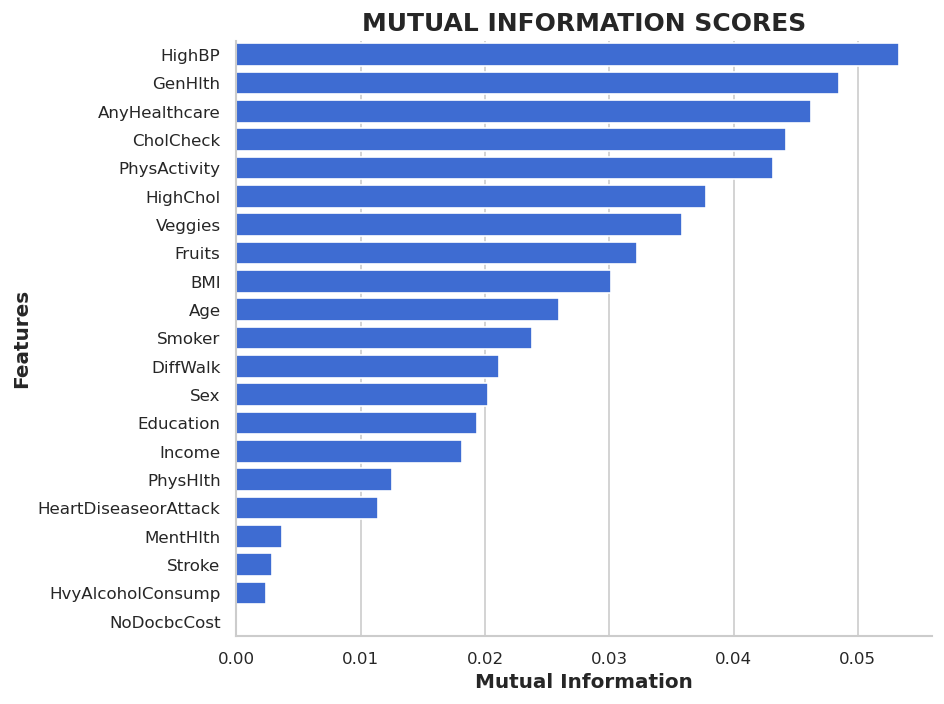

In [17]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index,
    color="#2563EB"
)

plt.title("MUTUAL INFORMATION SCORES")
plt.xlabel("Mutual Information")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

**Nhận xét**

- Kết quả Mutual Information cho thấy **HighBP**, **GenHlth**, **AnyHealthcare**, **CholCheck** và **PhysActivity** là những đặc trưng cung cấp nhiều thông tin nhất cho việc dự đoán nguy cơ mắc bệnh tiểu đường.
- Các đặc trưng như **BMI**, **Age**, **Smoker** và **DiffWalk** cũng có mức độ đóng góp đáng kể và sẽ được giữ lại trong mô hình.
- Ngược lại, **NoDocbcCost**, **HvyAlcoholConsump**, **Stroke** và **MentHlth** có điểm Mutual Information rất thấp, cho thấy lượng thông tin mà các biến này cung cấp cho biến mục tiêu còn hạn chế.
- Dựa trên kết quả này kết hợp với mục tiêu của bài toán, các đặc trưng có điểm MI thấp sẽ được xem xét loại bỏ nhằm giảm độ phức tạp của mô hình.

### **4.3 Remove Low-information Features**

Dựa trên kết quả Mutual Information, kết hợp với mục tiêu của bài toán và ý nghĩa của từng đặc trưng, các biến có mức đóng góp rất thấp được loại bỏ nhằm đơn giản hóa mô hình và giảm nhiễu trong dữ liệu.

In [18]:
low_features = [
    "Stroke",
    "MentHlth",
    "NoDocbcCost",
    "HvyAlcoholConsump"
]

df = df.drop(columns=low_features)

print("Phân tích các đặc trưng:")
print(df.shape)

Phân tích các đặc trưng:
(229781, 18)


In [19]:
df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,AnyHealthcare,GenHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,15.0,1.0,0.0,9.0,4.0,3.0,0.0
1,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,7.0,6.0,1.0,0.0
2,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,1.0,5.0,30.0,1.0,0.0,9.0,4.0,8.0,0.0
3,1.0,0.0,1.0,27.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,11.0,3.0,6.0,0.0
4,1.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,1.0,2.0,0.0,0.0,0.0,11.0,5.0,4.0,0.0


 **Nhận xét**

Sau khi đánh giá bằng Mutual Information, bốn đặc trưng gồm **NoDocbcCost**, **HvyAlcoholConsump**, **Stroke** và **MentHlth** được loại bỏ do có mức đóng góp rất thấp đối với biến mục tiêu. Các đặc trưng còn lại được giữ lại để phục vụ quá trình xây dựng mô hình.

## **5. Data Preprocessing**

### **5.1 Outlier Detection & Treatment**

Qua biểu đồ phân bố BMI và boxplot ở phần EDA, có thể thấy chỉ số BMI xuất hiện một số giá trị rất lớn.

Để hạn chế ảnh hưởng của các giá trị ngoại lệ nhưng vẫn giữ lại thông tin của dữ liệu, phương pháp **IQR (Interquartile Range)** được sử dụng để xác định và xử lý outliers.

In [20]:
# Outlier detection for BMI
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")

Lower bound: 12.00
Upper bound: 44.00


In [21]:
outliers = df[(df["BMI"] < lower) | (df["BMI"] > upper)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage: {len(outliers)/len(df)*100:.2f}%")

Number of outliers: 5638
Percentage: 2.45%


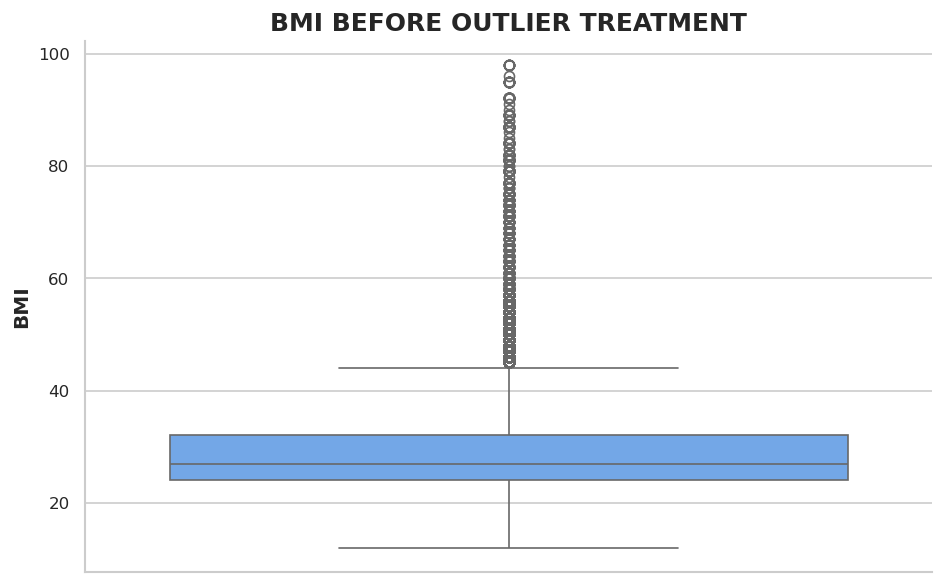

In [22]:
plt.figure()

sns.boxplot(
    y=df["BMI"],
    color="#60A5FA"
)

plt.title("BMI BEFORE OUTLIER TREATMENT")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

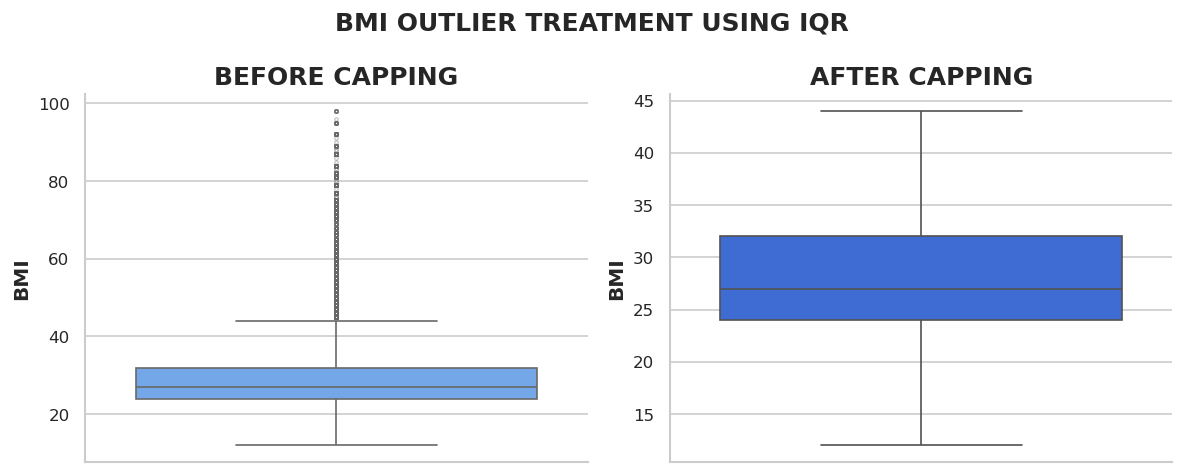

In [23]:
df_before = df.copy()
df["BMI"] = df["BMI"].clip(lower=lower, upper=upper)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
sns.boxplot(
    y=df_before["BMI"],
    color="#60A5FA",
    showfliers=True,
    flierprops=dict(
        marker='o',
        markersize=2,
        alpha=0.3
    ),
    ax=axes[0]
)

axes[0].set_title("BEFORE TREATMENT")
axes[0].set_ylabel("BMI")

# After
sns.boxplot(
    y=df["BMI"],
    color="#2563EB",
    showfliers=True,
    ax=axes[1]
)

axes[0].set_title("BEFORE CAPPING")
axes[1].set_title("AFTER CAPPING")

plt.suptitle(
    "BMI OUTLIER TREATMENT USING IQR",
    fontsize=15,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

**Nhận xét**

Kết quả cho thấy biến BMI xuất hiện một số giá trị ngoại lệ theo phương pháp IQR. Thay vì loại bỏ các quan sát này, phương pháp capping được áp dụng để giới hạn các giá trị vượt ngưỡng về khoảng cho phép. Cách tiếp cận này giúp giảm ảnh hưởng của ngoại lệ trong khi vẫn giữ nguyên số lượng mẫu của bộ dữ liệu.

### **5.2 Train / Validation / Test Split**

Bộ dữ liệu được chia thành ba tập:

- **Training set (70%)**: dùng để huấn luyện mô hình.
- **Validation set (15%)**: dùng để điều chỉnh siêu tham số và lựa chọn mô hình.
- **Test set (15%)**: dùng để đánh giá hiệu quả cuối cùng của mô hình trên dữ liệu chưa từng được sử dụng trong quá trình huấn luyện.

Việc chia dữ liệu theo tỷ lệ 70:15:15 giúp đảm bảo quá trình đánh giá khách quan và hạn chế hiện tượng overfitting.

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Diabetes_binary"])
y = df["Diabetes_binary"]

# Train (70%) - Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# Validation (15%) - Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Training set :", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set  :", X_test.shape)

Training set : (160846, 17)
Validation set: (34467, 17)
Testing set  : (34468, 17)


**Nhận xét**

Dữ liệu đã được chia thành ba tập theo tỷ lệ **70:15:15**. Đồng thời, tham số `stratify` được sử dụng để giữ nguyên tỷ lệ giữa hai lớp trong cả ba tập dữ liệu, giúp hạn chế sai lệch về phân bố lớp trong quá trình huấn luyện và đánh giá.

### **5.3 Feature Scaling**

Các đặc trưng được chuẩn hóa bằng **StandardScaler** nhằm đưa dữ liệu về cùng một thang đo.

Bộ chuẩn hóa được huấn luyện (fit) trên tập huấn luyện, sau đó áp dụng (transform) cho tập validation và tập test để tránh rò rỉ dữ liệu (data leakage).

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_val_scaled.shape)
print("Testing set:", X_test_scaled.shape)

Training set: (160846, 17)
Validation set: (34467, 17)
Testing set: (34468, 17)


**Nhận xét**

Sau khi chuẩn hóa, các đặc trưng được đưa về cùng một thang đo với trung bình xấp xỉ 0 và độ lệch chuẩn xấp xỉ 1. Điều này giúp các thuật toán dựa trên khoảng cách hoặc tối ưu hóa như Logistic Regression hoạt động hiệu quả hơn.

### **5.4 Handle Class Imbalance (SMOTE)**

Do bộ dữ liệu vẫn tồn tại sự mất cân bằng giữa hai lớp, kỹ thuật **SMOTE (Synthetic Minority Over-sampling Technique)** được áp dụng trên **tập huấn luyện đã được chuẩn hóa** nhằm tăng số lượng mẫu của lớp thiểu số.

Việc chỉ áp dụng SMOTE trên tập huấn luyện giúp tránh hiện tượng data leakage và cải thiện khả năng dự đoán của mô hình đối với lớp thiểu số.

In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
Diabetes_binary
0.0    133038
1.0     27808
Name: count, dtype: int64

After SMOTE
Diabetes_binary
0.0    133038
1.0    133038
Name: count, dtype: int64


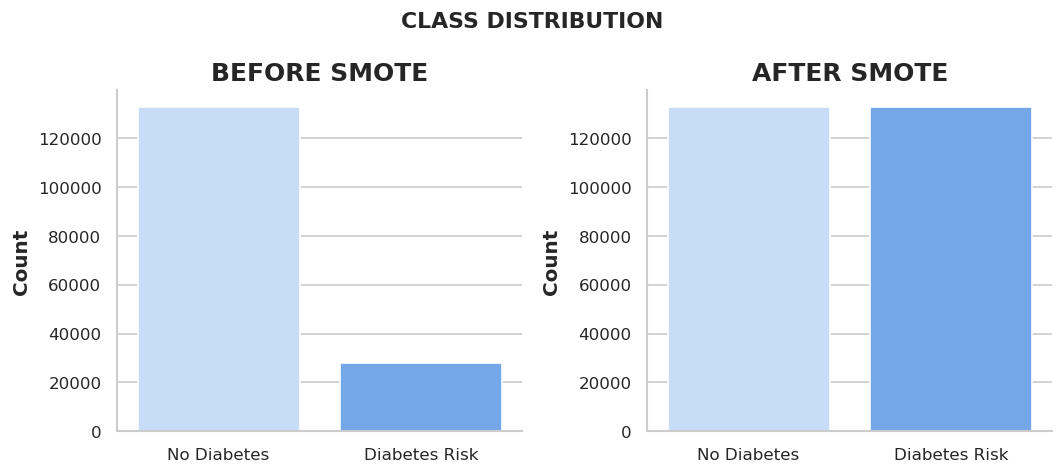

In [27]:
before = y_train.value_counts().sort_index()
after = y_train_smote.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Before SMOTE
sns.barplot(
    x=["No Diabetes", "Diabetes Risk"],
    y=before.values,
    palette=PALETTE[:2],
    ax=axes[0]
)

axes[0].set_title("BEFORE SMOTE")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

# After SMOTE
sns.barplot(
    x=["No Diabetes", "Diabetes Risk"],
    y=after.values,
    palette=PALETTE[:2],
    ax=axes[1]
)

axes[1].set_title("AFTER SMOTE")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

plt.suptitle("CLASS DISTRIBUTION", fontweight="bold")

plt.tight_layout()
plt.show()

**Nhận xét**

Trước khi áp dụng SMOTE, số lượng mẫu của lớp **Diabetes Risk** thấp hơn đáng kể so với lớp **No Diabetes**, thể hiện tình trạng mất cân bằng dữ liệu.

Sau khi áp dụng SMOTE, số lượng mẫu của hai lớp trở nên cân bằng. Điều này giúp mô hình học tốt hơn đối với lớp thiểu số và giảm xu hướng dự đoán thiên lệch về lớp chiếm ưu thế.

## **6. Model Building**

Trước khi huấn luyện các mô hình, dữ liệu được chia thành tập huấn luyện, tập validation và tập kiểm tra, đồng thời được chuẩn hóa bằng StandardScaler. Đối với bài toán mất cân bằng dữ liệu, mỗi mô hình áp dụng phương pháp xử lý phù hợp với đặc điểm của thuật toán nhằm cải thiện khả năng dự đoán lớp thiểu số:

- **Logistic Regression:** sử dụng **SMOTE** để cân bằng dữ liệu huấn luyện.
- **Random Forest:** sử dụng **class_weight="balanced"** để tăng trọng số cho lớp thiểu số trong quá trình xây dựng cây quyết định.
- **XGBoost:** sử dụng **scale_pos_weight** nhằm điều chỉnh trọng số giữa hai lớp trong quá trình huấn luyện.

### **6.1 Logistic Regression**

Logistic Regression được lựa chọn làm mô hình cơ sở (baseline) để đánh giá hiệu quả của các mô hình nâng cao. Đây là thuật toán phân loại tuyến tính, có khả năng diễn giải tốt và thường được sử dụng trong các bài toán phân loại nhị phân.

**Train model**

In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

**Prediction**

In [29]:
y_pred_log = log_model.predict(X_val_scaled)
y_prob_log = log_model.predict_proba(X_val_scaled)[:, 1]

**Evaluation**

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Evaluation Metrics
evaluation_log = pd.DataFrame(
    {
        "Score": [
            accuracy_score(y_val, y_pred_log),
            precision_score(y_val, y_pred_log),
            recall_score(y_val, y_pred_log),
            f1_score(y_val, y_pred_log),
            roc_auc_score(y_val, y_prob_log),
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
)

evaluation_log = evaluation_log.round(4)

display(evaluation_log)


,Score
Accuracy,0.7191
Precision,0.3539
Recall,0.7565
F1-score,0.4822
ROC-AUC,0.8045


**Classification Report**

In [31]:
print("\nClassification Report")
print(classification_report(y_val, y_pred_log))


Classification Report
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81     28508
         1.0       0.35      0.76      0.48      5959

    accuracy                           0.72     34467
   macro avg       0.64      0.73      0.64     34467
weighted avg       0.83      0.72      0.75     34467



**Nhận xét**

- Logistic Regression đạt **Accuracy khoảng 72%**, cho thấy mô hình có khả năng phân loại tương đối tốt trên tập validation.
- Mô hình đạt **Recall 76%** đối với lớp **Diabetes Risk**, nghĩa là phát hiện được phần lớn các trường hợp có nguy cơ mắc bệnh.
- **Precision chỉ đạt 35%**, cho thấy vẫn còn nhiều trường hợp dự đoán dương tính nhưng thực tế không mắc bệnh (False Positives).
- **F1-score đạt 0.48**, phản ánh sự cân bằng giữa Precision và Recall ở mức trung bình.
- **ROC-AUC đạt khoảng 0.80**, cho thấy mô hình có khả năng phân biệt tương đối tốt giữa hai lớp *No Diabetes* và *Diabetes Risk*, vượt đáng kể so với mô hình dự đoán ngẫu nhiên.
- Nhìn chung, Logistic Regression là mô hình baseline phù hợp để so sánh với các mô hình nâng cao như Random Forest và XGBoost trong các bước tiếp theo.

**Confusion Matrix**

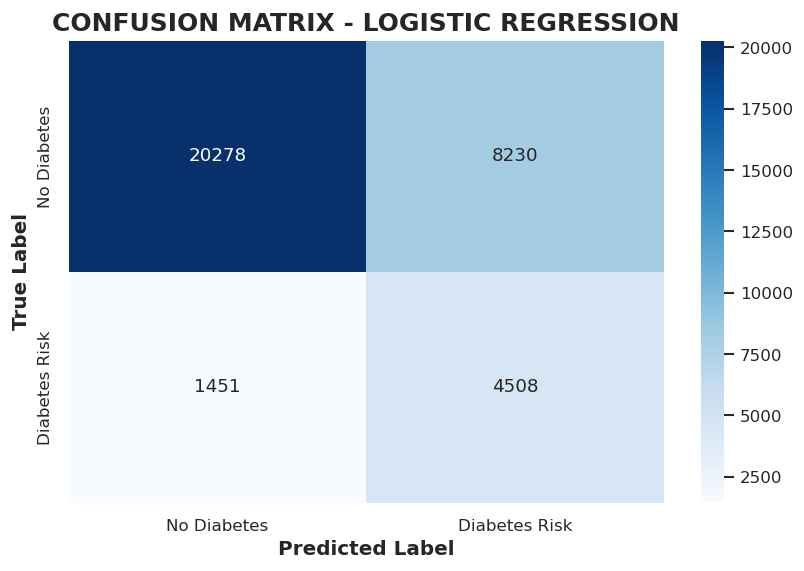

In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred_log)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes Risk"],
    yticklabels=["No Diabetes", "Diabetes Risk"]
)

plt.title("CONFUSION MATRIX - LOGISTIC REGRESSION")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**Nhận xét**

- Mô hình dự đoán đúng **20,278** trường hợp không mắc bệnh (True Negatives) và **4,508** trường hợp có nguy cơ mắc bệnh (True Positives).
- Có **1,451** trường hợp thuộc lớp Diabetes Risk bị dự đoán nhầm là không mắc bệnh (False Negatives).
- Đồng thời, mô hình dự đoán nhầm **8,230** trường hợp không mắc bệnh thành có nguy cơ mắc bệnh (False Positives).
- Kết quả cho thấy mô hình có xu hướng ưu tiên phát hiện lớp Diabetes Risk, tuy nhiên vẫn còn tạo ra số lượng False Positives tương đối lớn.

### **6.2 Random Forest**

Random Forest là thuật toán học máy thuộc nhóm **ensemble learning**, hoạt động bằng cách kết hợp nhiều cây quyết định để đưa ra kết quả dự đoán cuối cùng. So với Logistic Regression, Random Forest có khả năng học được các mối quan hệ phi tuyến giữa các đặc trưng và biến mục tiêu, đồng thời giúp giảm hiện tượng quá khớp nhờ cơ chế tổng hợp kết quả từ nhiều cây quyết định.

**Train model**

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    criterion="gini",
    bootstrap=True,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

**Prediction**

In [34]:
y_pred_rf = rf_model.predict(X_val_scaled)
y_prob_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

**Evaluation**

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

evaluation_rf = pd.DataFrame(
    {
        "Score": [
            accuracy_score(y_val, y_pred_rf),
            precision_score(y_val, y_pred_rf),
            recall_score(y_val, y_pred_rf),
            f1_score(y_val, y_pred_rf),
            roc_auc_score(y_val, y_prob_rf),
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
)

evaluation_rf = evaluation_rf.round(4)

display(evaluation_rf)

,Score
Accuracy,0.7601
Precision,0.3867
Recall,0.6622
F1-score,0.4883
ROC-AUC,0.8043


**Classification Report**

In [36]:
print(classification_report(y_val, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.92      0.78      0.84     28508
         1.0       0.39      0.66      0.49      5959

    accuracy                           0.76     34467
   macro avg       0.65      0.72      0.67     34467
weighted avg       0.83      0.76      0.78     34467





**Nhận xét**

- Random Forest đạt **Accuracy khoảng 76%**, cho thấy mô hình có khả năng phân loại tương đối tốt trên tập validation.
- **Recall đạt 66%** đối với lớp **Diabetes Risk**, nghĩa là mô hình phát hiện được phần lớn các trường hợp có nguy cơ mắc bệnh và cao hơn so với Logistic Regression.
- **Precision đạt khoảng 39%**, phản ánh vẫn còn một số trường hợp dự đoán dương tính nhưng thực tế không thuộc lớp **Diabetes Risk**.
- **F1-score đạt 0.4883**, cho thấy mô hình duy trì được sự cân bằng tốt giữa Precision và Recall.
- **ROC-AUC đạt 0.8043**, thể hiện khả năng phân biệt giữa hai lớp ở mức tốt và nhỉnh hơn Logistic Regression.
- Nhìn chung, Random Forest đạt được sự cân bằng tốt giữa khả năng phát hiện lớp **Diabetes Risk** và hiệu quả phân loại tổng thể, phù hợp để so sánh với XGBoost ở bước tiếp theo.

**Confusion Matrix**

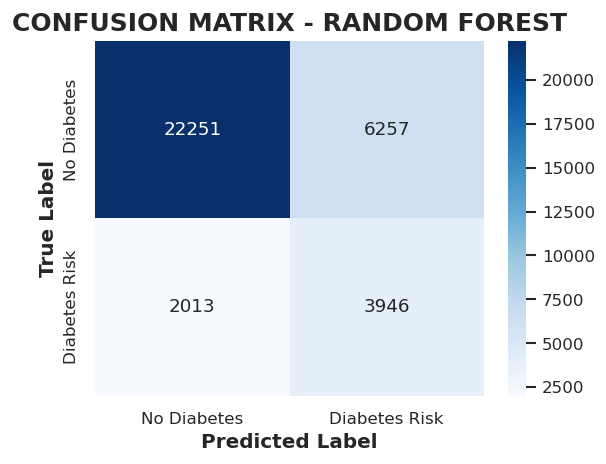

In [37]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_val, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes Risk"],
    yticklabels=["No Diabetes", "Diabetes Risk"]
)

plt.title("CONFUSION MATRIX - RANDOM FOREST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

**Nhận xét**

- Mô hình dự đoán đúng **22,251** trường hợp thuộc lớp **No Diabetes** (True Negatives), cho thấy khả năng nhận diện các trường hợp không mắc bệnh tương đối tốt.
- Đồng thời, mô hình dự đoán đúng **3,946** trường hợp thuộc lớp **Diabetes Risk** (True Positives), phản ánh khả năng phát hiện các đối tượng có nguy cơ mắc bệnh khá hiệu quả.
- Có **6,257** trường hợp **No Diabetes** bị dự đoán nhầm thành **Diabetes Risk** (False Positives), làm giảm Precision của mô hình.
- Mô hình bỏ sót **2,013** trường hợp thực sự thuộc lớp **Diabetes Risk** (False Negatives), tuy nhiên số lượng này thấp hơn so với Logistic Regression, góp phần cải thiện khả năng phát hiện lớp thiểu số.
- Nhìn chung, Random Forest ưu tiên phát hiện các trường hợp có nguy cơ mắc bệnh, thể hiện qua số lượng **True Positives** cao và **Recall đạt khoảng 66%**. Điều này giúp mô hình phù hợp với bài toán sàng lọc nguy cơ mắc bệnh tiểu đường, mặc dù vẫn còn một số lượng đáng kể các trường hợp dương tính giả.

### **6.3 XGBoost**

XGBoost (Extreme Gradient Boosting) là thuật toán học máy dựa trên phương pháp Gradient Boosting, được tối ưu về hiệu suất và tốc độ huấn luyện. Thuật toán có khả năng khai thác hiệu quả các mối quan hệ phức tạp giữa các đặc trưng, đồng thời tích hợp nhiều cơ chế giúp hạn chế hiện tượng quá khớp. XGBoost được kỳ vọng sẽ đạt hiệu quả dự đoán cao hơn so với Logistic Regression và Random Forest.

**Train Model**

In [38]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

**Prediction**

In [39]:
y_pred_xgb = xgb_model.predict(X_val_scaled)
y_prob_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]

**Evaluation**

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

evaluation_xgb = pd.DataFrame(
    {
        "Score": [
            accuracy_score(y_val, y_pred_xgb),
            precision_score(y_val, y_pred_xgb),
            recall_score(y_val, y_pred_xgb),
            f1_score(y_val, y_pred_xgb),
            roc_auc_score(y_val, y_prob_xgb),
        ]
    },
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
    ],
)

evaluation_xgb = evaluation_xgb.round(4)

display(evaluation_xgb)

,Score
Accuracy,0.7176
Precision,0.3528
Recall,0.7589
F1-score,0.4817
ROC-AUC,0.8071


**Classification Report**

In [41]:
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81     28508
         1.0       0.35      0.76      0.48      5959

    accuracy                           0.72     34467
   macro avg       0.64      0.73      0.64     34467
weighted avg       0.83      0.72      0.75     34467




**Nhận xét**

- XGBoost đạt **Accuracy khoảng 72%**, cho thấy mô hình có khả năng phân loại tương đối tốt trên tập validation.
- **Recall đạt khoảng 76%** đối với lớp **Diabetes Risk**, nghĩa là mô hình phát hiện được phần lớn các trường hợp có nguy cơ mắc bệnh.
- **Precision đạt khoảng 35%**, phản ánh vẫn còn một số lượng đáng kể các trường hợp được dự đoán là **Diabetes Risk** nhưng thực tế không thuộc lớp này.
- **F1-score đạt 0.4817**, cho thấy mô hình duy trì được sự cân bằng tương đối giữa Precision và Recall.
- **ROC-AUC đạt 0.8071**, thể hiện khả năng phân biệt giữa hai lớp ở mức tốt và nhỉnh hơn Logistic Regression.
- Nhìn chung, XGBoost có khả năng phát hiện lớp **Diabetes Risk** tốt, đồng thời đạt ROC-AUC cao, phù hợp để so sánh với Logistic Regression và Random Forest trong phần đánh giá mô hình.

**Confusion Matrix**

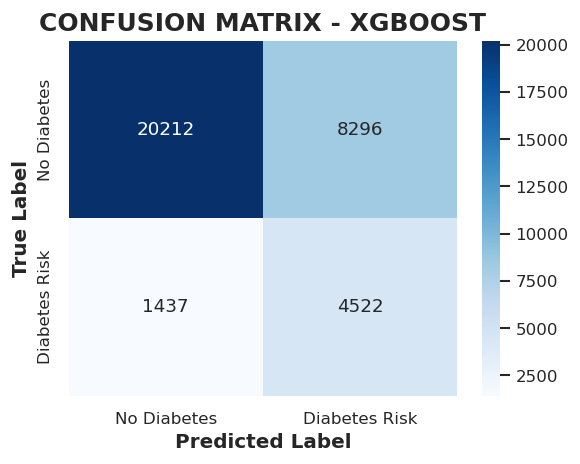

In [42]:
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_val, y_pred_xgb)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes Risk"],
    yticklabels=["No Diabetes", "Diabetes Risk"]
)

plt.title("CONFUSION MATRIX - XGBOOST")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

**Nhận xét**

- Mô hình dự đoán đúng **20,212** trường hợp thuộc lớp **No Diabetes** (True Negatives), phản ánh khả năng nhận diện các trường hợp không mắc bệnh ở mức tương đối tốt.
- Đồng thời, mô hình dự đoán đúng **4,522** trường hợp thuộc lớp **Diabetes Risk** (True Positives), cho thấy khả năng phát hiện các đối tượng có nguy cơ mắc bệnh khá hiệu quả.
- Có **8,296** trường hợp **No Diabetes** bị dự đoán nhầm thành **Diabetes Risk** (False Positives), làm giảm Precision của mô hình.
- Mô hình chỉ bỏ sót **1,437** trường hợp thực sự thuộc lớp **Diabetes Risk** (False Negatives), là số lượng thấp nhất trong ba mô hình, góp phần giúp **Recall đạt khoảng 76%**.
- Nhìn chung, XGBoost ưu tiên phát hiện các trường hợp có nguy cơ mắc bệnh, thể hiện qua số lượng **True Positives** cao và **False Negatives** thấp. Mặc dù số lượng **False Positives** còn tương đối lớn, mô hình phù hợp với bài toán sàng lọc nguy cơ mắc bệnh tiểu đường, trong đó việc hạn chế bỏ sót các trường hợp có nguy cơ được ưu tiên hơn.

## **7. Model Comparison**

Sau khi xây dựng và đánh giá ba mô hình gồm Logistic Regression, Random Forest và XGBoost, các chỉ số đánh giá được tổng hợp để so sánh hiệu quả dự đoán. Việc so sánh dựa trên các chỉ số Accuracy, Precision, Recall, F1-score và ROC-AUC nhằm lựa chọn mô hình phù hợp nhất cho bài toán dự đoán nguy cơ mắc bệnh tiểu đường.

### **7.1 Performance Comparison**

In [43]:
comparison_df = pd.concat(
    [
        evaluation_log.T,
        evaluation_rf.T,
        evaluation_xgb.T
    ]
)

comparison_df.index = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
]

display(comparison_df)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.7191,0.3539,0.7565,0.4822,0.8045
Random Forest,0.7601,0.3867,0.6622,0.4883,0.8043
XGBoost,0.7176,0.3528,0.7589,0.4817,0.8071


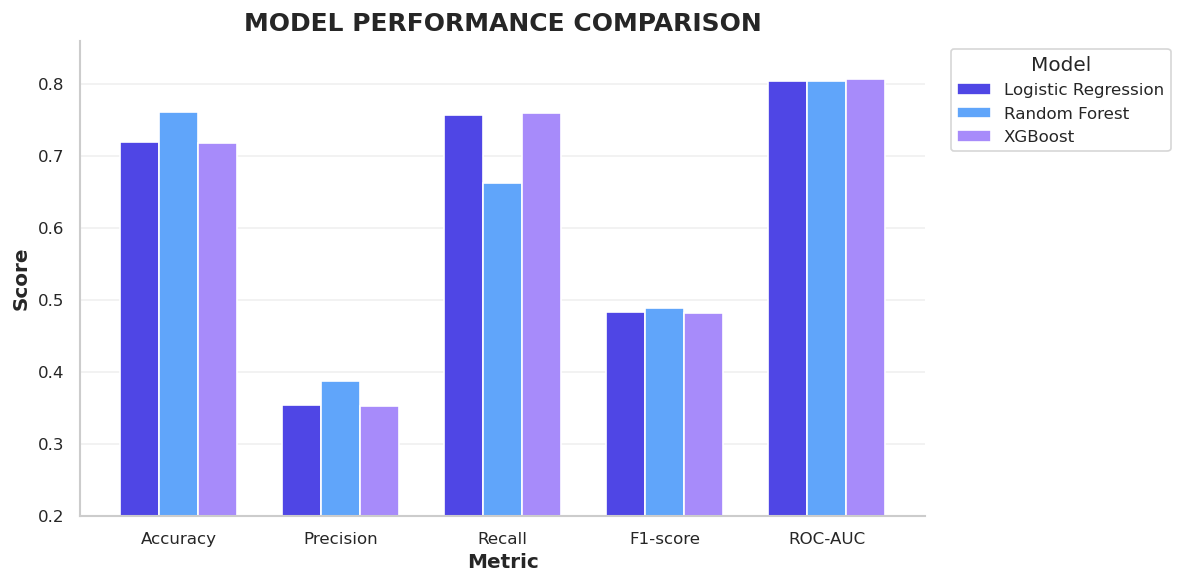

In [44]:
colors = [
    "#4F46E5",   # Indigo
    "#60A5FA",   # Sky Blue
    "#A78BFA"    # Lavender
]

ax = comparison_df.T.plot(
    kind="bar",
    figsize=(10,5),
    width=0.72,
    color=colors,
    edgecolor="white"
)

plt.title("MODEL PERFORMANCE COMPARISON")
plt.xlabel("Metric")
plt.ylabel("Score")

plt.ylim(0.2,0.86)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)
plt.grid(axis="x", visible=False)


# Legend
plt.legend(
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.02,1),
    frameon=True
)

plt.tight_layout()

plt.show()


**Nhận xét**

- **Logistic Regression** đạt **Recall = 75.65%**, cho thấy khả năng phát hiện các trường hợp có nguy cơ mắc bệnh khá tốt. Tuy nhiên, Accuracy và Precision còn thấp, dẫn đến số lượng dự đoán dương tính giả tương đối lớn.
- **Random Forest** đạt **Accuracy = 76.01%** và **F1-score = 0.4883**, cao nhất trong ba mô hình. Điều này cho thấy mô hình duy trì được sự cân bằng tốt giữa Precision và Recall, đồng thời cải thiện hiệu quả phân loại tổng thể.
- **XGBoost** đạt **ROC-AUC = 0.8071**, cao nhất trong ba mô hình, đồng thời có **Recall = 75.89%**, cho thấy khả năng phân biệt giữa hai lớp và phát hiện các trường hợp có nguy cơ mắc bệnh rất tốt. Tuy nhiên, Precision vẫn chưa được cải thiện đáng kể so với Logistic Regression.
- Nhìn chung, cả ba mô hình đều có những ưu điểm riêng. Logistic Regression và XGBoost phù hợp khi ưu tiên **Recall** để giảm số lượng trường hợp có nguy cơ mắc bệnh bị bỏ sót, trong khi Random Forest đạt hiệu quả cân bằng hơn giữa các chỉ số đánh giá.


### **7.2 ROC Curve Comparison**

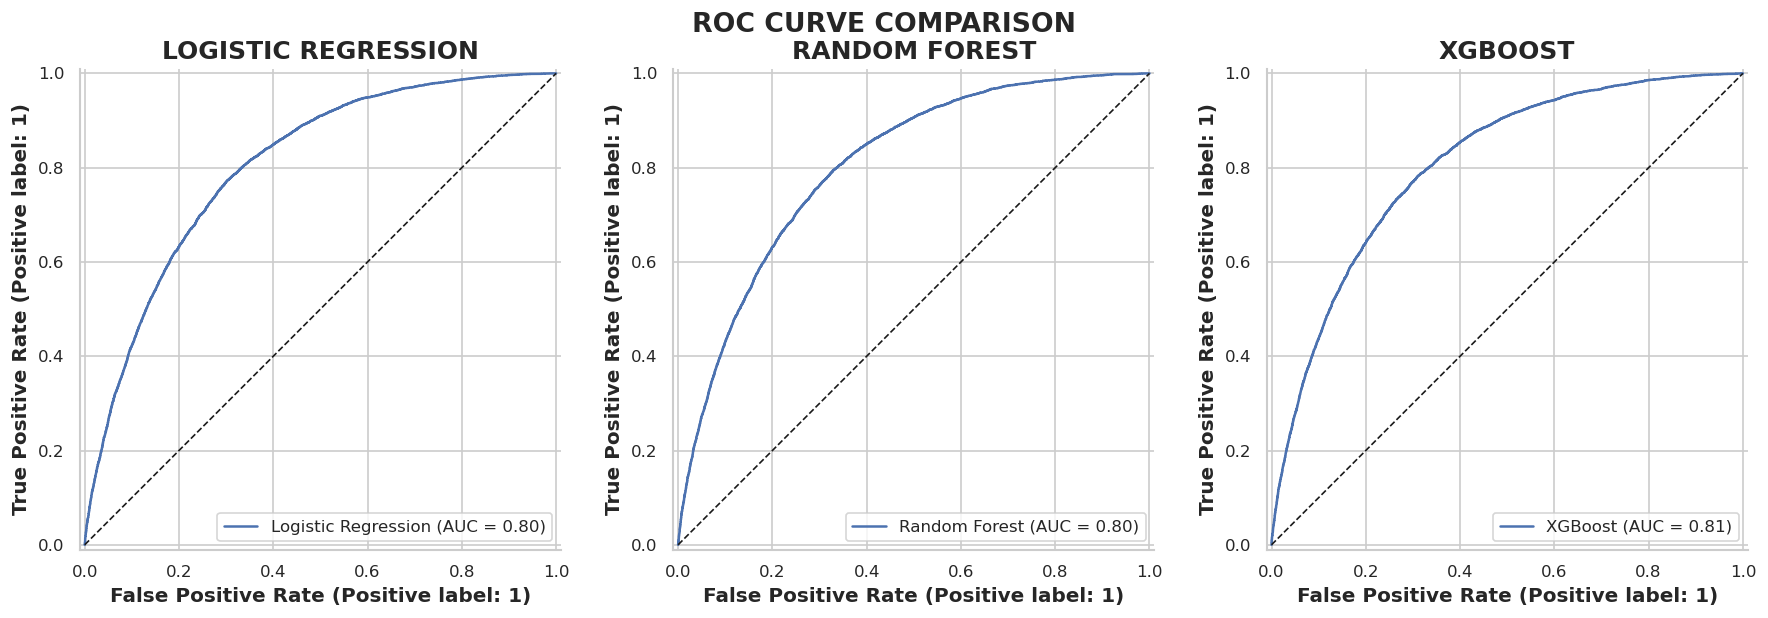

In [45]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Logistic Regression
RocCurveDisplay.from_predictions(
    y_val,
    y_prob_log,
    name="Logistic Regression",
    ax=axes[0]
)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set_title("LOGISTIC REGRESSION")

# Random Forest
RocCurveDisplay.from_predictions(
    y_val,
    y_prob_rf,
    name="Random Forest",
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_title("RANDOM FOREST")

# XGBoost
RocCurveDisplay.from_predictions(
    y_val,
    y_prob_xgb,
    name="XGBoost",
    ax=axes[2]
)
axes[2].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[2].set_title("XGBOOST")

plt.suptitle("ROC CURVE COMPARISON", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()



**Nhận xét**

- Cả ba mô hình đều có đường cong ROC nằm phía trên đường chéo tham chiếu (đường phân loại ngẫu nhiên), cho thấy các mô hình đều có khả năng phân biệt giữa hai lớp **No Diabetes** và **Diabetes Risk** tốt hơn so với dự đoán ngẫu nhiên.
- Giá trị **ROC-AUC** của ba mô hình đều đạt khoảng **0.80**, phản ánh khả năng phân biệt giữa hai lớp ở mức tốt.
- **XGBoost** đạt **ROC-AUC = 0.8071**, cao nhất trong ba mô hình, cho thấy khả năng xếp hạng xác suất dự đoán nhỉnh hơn so với Logistic Regression và Random Forest.
- **Random Forest** đạt **ROC-AUC = 0.8043**, trong khi **Logistic Regression** đạt **ROC-AUC = 0.8000**. Mặc dù có sự khác biệt, khoảng cách giữa các giá trị ROC-AUC là không lớn.
- Nhìn chung, ba mô hình đều có hiệu quả phân biệt hai lớp tương đối tương đồng. Vì vậy, việc lựa chọn mô hình cuối cùng cần kết hợp thêm các chỉ số khác như **Recall**, **Precision** và **F1-score**, thay vì chỉ dựa trên ROC-AUC.

### **7.3 Overfitting Check**
Để đánh giá khả năng khái quát hóa của các mô hình, tiến hành so sánh độ chính xác (Accuracy) trên tập huấn luyện và tập validation. Nếu chênh lệch giữa hai tập quá lớn, mô hình có thể đã xảy ra hiện tượng overfitting.

In [46]:
# Training Accuracy
train_acc_log = accuracy_score(
    y_train_smote,
    log_model.predict(X_train_smote)
)

train_acc_rf = accuracy_score(
    y_train,
    rf_model.predict(X_train_scaled)
)

train_acc_xgb = accuracy_score(
    y_train,
    xgb_model.predict(X_train_scaled)
)

# Validation Accuracy
val_acc_log = accuracy_score(y_val, y_pred_log)
val_acc_rf = accuracy_score(y_val, y_pred_rf)
val_acc_xgb = accuracy_score(y_val, y_pred_xgb)

overfitting_df = pd.DataFrame(
    {
        "Training Accuracy": [
            train_acc_log,
            train_acc_rf,
            train_acc_xgb
        ],
        "Validation Accuracy": [
            val_acc_log,
            val_acc_rf,
            val_acc_xgb
        ]
    },
    index=[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

overfitting_df = overfitting_df.round(4)

overfitting_df["Gap"] = (
    overfitting_df["Training Accuracy"]
    - overfitting_df["Validation Accuracy"]
).round(4)

display(overfitting_df)

,Training Accuracy,Validation Accuracy,Gap
Logistic Regression,0.7345,0.7191,0.0154
Random Forest,0.8136,0.7601,0.0535
XGBoost,0.7366,0.7176,0.0190


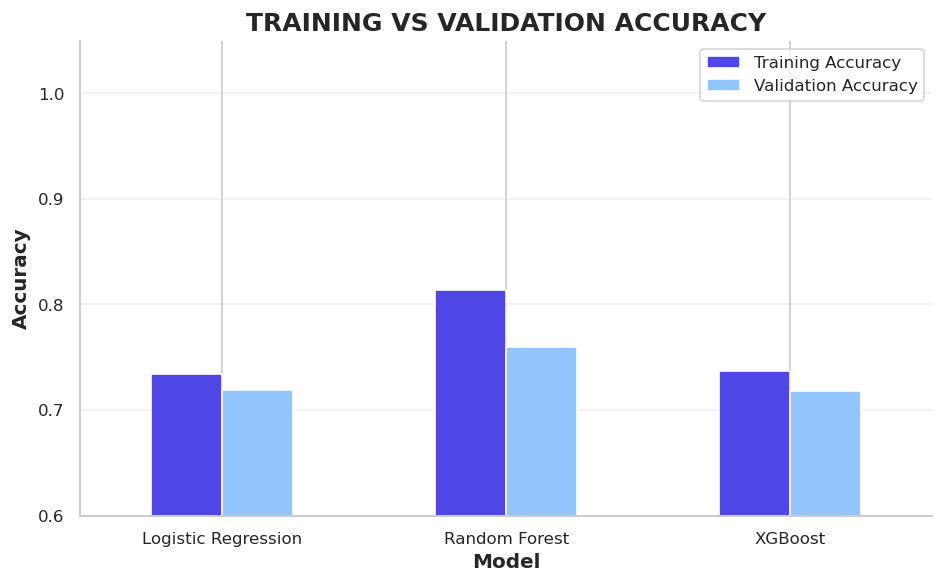

In [47]:
ax = overfitting_df[
    ["Training Accuracy", "Validation Accuracy"]
].plot(
    kind="bar",
    figsize=(8, 5),
    color=["#4F46E5", "#93C5FD"],
    edgecolor="white"
)

plt.title("TRAINING VS VALIDATION ACCURACY")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.ylim(0.6, 1.05)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(frameon=True)

plt.tight_layout()

plt.show()


**Nhận xét**

Bảng so sánh cho thấy **Logistic Regression** và **XGBoost** có độ chênh lệch giữa **Training Accuracy** và **Validation Accuracy** khá nhỏ (lần lượt **0.0154** và **0.0190**), cho thấy hai mô hình có khả năng tổng quát hóa tốt và hầu như không xuất hiện hiện tượng overfitting.

Trong khi đó, **Random Forest** có **Gap = 0.0535**, lớn hơn hai mô hình còn lại. Điều này cho thấy mô hình có xu hướng học sát dữ liệu huấn luyện hơn, tuy nhiên mức chênh lệch vẫn chưa quá lớn và chỉ phản ánh dấu hiệu **overfitting nhẹ**.

### **Conclusion**

Dựa trên kết quả so sánh, **XGBoost** được lựa chọn là mô hình để tiếp tục tối ưu trong các bước tiếp theo. Mặc dù Accuracy và F1-score chưa cao nhất, mô hình đạt **Recall (75.89%)** và **ROC-AUC (0.8071)** cao nhất trong ba mô hình, cho thấy khả năng phát hiện các trường hợp có nguy cơ mắc bệnh và phân biệt giữa hai lớp tốt hơn. Đây là những tiêu chí quan trọng đối với bài toán dự đoán nguy cơ mắc bệnh tiểu đường, vì vậy XGBoost được lựa chọn để tiếp tục tối ưu siêu tham số và đánh giá trên tập kiểm tra.

## **8. XGBoost Hyperparameter Tuning**

Sau khi so sánh ba mô hình, XGBoost được lựa chọn để tiếp tục tối ưu do đạt Recall và ROC-AUC cao nhất. Ở bước này, mô hình được tinh chỉnh các siêu tham số bằng **GridSearchCV** nhằm tìm ra bộ tham số tối ưu, từ đó cải thiện hiệu quả dự đoán trên tập validation.

### **8.1 Define Parameter Grid**

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

### **8.2 Define Parameter Grid**

In [49]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_tuned = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

### **8.3 Grid Search**

GridSearchCV được sử dụng kết hợp với **5-fold Cross Validation** để tìm bộ siêu tham số tối ưu. Tiêu chí đánh giá là **F1-score**, giúp cân bằng giữa Precision và Recall trên dữ liệu mất cân bằng.

In [50]:
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_xgb = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


### **8.4 Best Parameters**

In [51]:
best_params = pd.DataFrame(
    grid_search.best_params_.items(),
    columns=["Parameter", "Value"]
)

display(best_params)

print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

,Parameter,Value
0,colsample_bytree,1.00
1,learning_rate,0.05
2,max_depth,7.00
3,n_estimators,200.00
4,subsample,0.80


Best CV F1-score: 0.4765


### **8.5 Conclusion**

- Sau quá trình **GridSearchCV** với **5-fold Cross Validation**, mô hình XGBoost xác định được bộ siêu tham số tối ưu gồm:
  - `n_estimators = 200`
  - `max_depth = 7`
  - `learning_rate = 0.05`
  - `subsample = 0.8`
  - `colsample_bytree = 1.0`

- Bộ siêu tham số tối ưu đạt **Best CV F1-score = 0.4765**, cho thấy mô hình duy trì khả năng cân bằng giữa Precision và Recall khá tốt trong quá trình đánh giá chéo.

- Kết quả cho thấy mô hình lựa chọn **200 cây boosting** kết hợp với **độ sâu cây bằng 7**, giúp học hiệu quả các mối quan hệ phi tuyến và tương tác giữa các yếu tố nguy cơ trong dữ liệu.

- Giá trị **learning_rate = 0.05** cho thấy mô hình ưu tiên quá trình cập nhật ổn định hơn, góp phần giảm nguy cơ overfitting khi kết hợp với số lượng cây lớn.

- Tham số **subsample = 0.8** giúp tăng tính đa dạng giữa các cây bằng cách chỉ sử dụng một phần dữ liệu trong mỗi vòng boosting, từ đó cải thiện khả năng tổng quát hóa của mô hình.

- Giá trị **colsample_bytree = 1.0** cho thấy việc sử dụng toàn bộ tập đặc trưng khi xây dựng mỗi cây là cấu hình phù hợp nhất trong phạm vi không gian tham số được khảo sát.

- Nhìn chung, bộ siêu tham số tối ưu giúp mô hình đạt hiệu quả học ổn định trên các tập dữ liệu của quá trình cross-validation và được lựa chọn để tiếp tục tối ưu ngưỡng phân loại ở bước tiếp theo.

## **9. Threshold Optimization**

Mặc định, XGBoost sử dụng ngưỡng phân loại **0.5** để chuyển đổi xác suất dự đoán thành nhãn lớp. Tuy nhiên, đối với bài toán dự đoán nguy cơ mắc bệnh tiểu đường, việc sử dụng ngưỡng mặc định có thể chưa mang lại sự cân bằng tốt giữa Precision và Recall.

Vì vậy, bước này tiến hành khảo sát nhiều giá trị threshold khác nhau nhằm lựa chọn ngưỡng phân loại tối ưu dựa trên **F1-score**, từ đó cải thiện hiệu quả phát hiện các trường hợp có nguy cơ mắc bệnh.

### **9.1 Generate Prediction Probabilities**

In [52]:
# Predict probabilities on the validation set
y_prob = best_xgb.predict_proba(X_val_scaled)[:, 1]

### **9.2 Search for the Best Threshold**

In [53]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    results.append([
        threshold,
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred)
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1-score"
    ]
)

threshold_df.round(4)

,Threshold,Precision,Recall,F1-score
0,0.10,0.2114,0.9837,0.3480
1,0.15,0.2270,0.9705,0.3680
2,0.20,0.2429,0.9537,0.3872
3,0.25,0.2586,0.9340,0.4050
4,0.30,0.2755,0.9136,0.4234
5,0.35,0.2931,0.8861,0.4405
6,0.40,0.3114,0.8537,0.4563
7,0.45,0.3294,0.8161,0.4693
8,0.50,0.3502,0.7716,0.4818
9,0.55,0.3755,0.7167,0.4928


### **9.3 Best Threshold**

In [54]:
best_threshold = threshold_df.loc[
    threshold_df["F1-score"].idxmax()
]

best_threshold

Threshold    0.600000
Precision    0.405758
Recall       0.652794
F1-score     0.500450
Name: 10, dtype: float64

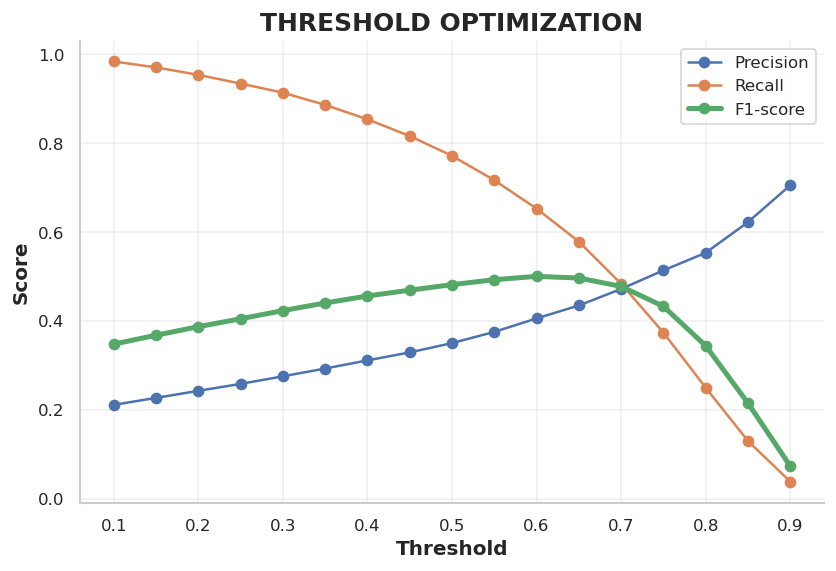

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker="o",
    linewidth=3,
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("THRESHOLD OPTIMIZATION")

plt.grid(alpha=0.3)

plt.legend()

plt.show()


**Nhận xét**

- Kết quả khảo sát cho thấy khi **threshold tăng**, **Precision** có xu hướng tăng trong khi **Recall** giảm. Điều này phản ánh sự đánh đổi giữa việc giảm số lượng dự đoán dương tính sai và nguy cơ bỏ sót các trường hợp có nguy cơ mắc bệnh.

- **F1-score** tăng dần khi threshold được điều chỉnh từ **0.10** đến **0.60**, sau đó giảm khi threshold tiếp tục tăng. Điều này cho thấy **threshold = 0.60** mang lại sự cân bằng tốt nhất giữa Precision và Recall.

- Tại **threshold = 0.60**, mô hình đạt:
  - **Precision = 0.4058**
  - **Recall = 0.6528**
  - **F1-score = 0.5005**

- So với việc sử dụng ngưỡng mặc định, threshold tối ưu giúp cải thiện F1-score, đồng thời vẫn duy trì Recall ở mức tương đối cao. Điều này phù hợp với mục tiêu phát hiện các trường hợp có nguy cơ mắc bệnh mà vẫn hạn chế số lượng dự đoán dương tính sai.

- Dựa trên kết quả tối ưu ngưỡng phân loại, **threshold = 0.60** được lựa chọn làm ngưỡng dự đoán cuối cùng cho mô hình XGBoost. Ngưỡng này đạt **F1-score = 0.5005**, đồng thời duy trì sự cân bằng giữa Precision và Recall. Bộ tham số tối ưu cùng với threshold đã lựa chọn sẽ được sử dụng để huấn luyện lại mô hình và đánh giá trên tập kiểm tra ở bước tiếp theo.

## **10. Final Model Evaluation**

Sau khi xác định được bộ siêu tham số tối ưu và ngưỡng phân loại phù hợp, mô hình XGBoost được huấn luyện lại trên toàn bộ dữ liệu **Training + Validation** nhằm tận dụng tối đa dữ liệu phục vụ quá trình học.

Cuối cùng, mô hình được đánh giá trên **tập Test** để phản ánh khách quan khả năng tổng quát hóa đối với dữ liệu chưa từng được sử dụng trong quá trình huấn luyện và tối ưu.

### **10.1 Retrain on Training + Validation Set**

In [57]:
import numpy as np

# Combine Training and Validation sets
X_train_final = np.concatenate(
    [X_train_scaled, X_val_scaled],
    axis=0
)

y_train_final = np.concatenate(
    [y_train, y_val]
)

In [58]:
print(X_train_final.shape)
print(y_train_final.shape)

(195313, 17)
(195313,)
